In [1]:
 %load_ext autoreload
%autoreload 2
import networkx as nx
import numpy as np
import csv
import os
import os.path as osp
from hydra import compose, initialize
from hydra.utils import instantiate
from hydra.core.global_hydra import GlobalHydra  # Import GlobalHydra explicitly
from ogbench.utils.config_resolvers import (
    get_default_transform,
    get_monitor_metric,
    get_monitor_mode,
    infer_in_channels,
)
import pandas as pd

# Clear GlobalHydra instance if already initialized
if GlobalHydra().is_initialized():
    GlobalHydra().clear()

initialize(config_path="../configs", job_name="job")

/home/lcornelis/anaconda3/envs/proteo/lib/python3.11/site-packages/torch_geometric/typing.py:155: UserWarning: An issue occurred while importing 'torch-spline-conv'. Disabling its usage. Stacktrace: /home/lcornelis/anaconda3/envs/proteo/lib/python3.11/site-packages/torch_spline_conv/_version_cuda.so: undefined symbol: _ZN3c1017RegisterOperatorsD1Ev
  warnings.warn(
/tmp/ipykernel_866754/1173261598.py:23: UserWarning: 
The version_base parameter is not specified.
Please specify a compatability version level, or None.
Will assume defaults for version 1.1
  initialize(config_path="../configs", job_name="job")


hydra.initialize()

In [2]:
dataset_name = "addneuromed"

cfg = compose(
    config_name="train.yaml",
    overrides=[
        "model=gat",
        f"dataset={dataset_name}",
        "dataset.loader.parameters.adjacency_threshold=0.5",
        "dataset.loader.parameters.node_sample_ratio=full",
    ], 
    return_hydra_config=True
)
loader = instantiate(cfg.dataset.loader)
dataset = loader.load_dataset()
print(dataset.processed_dir)
print(dataset[0])

def load_dataset(dataset_name, adj_thresh=0.5):
    """
    Load the FTD dataset with a specified adjacency threshold.
    """
    cfg = compose(
        config_name="train.yaml",
        overrides=[
            "model=gat",
            f"dataset={dataset_name}",
            f"dataset.loader.parameters.adjacency_threshold={adj_thresh}",
            f"dataset.loader.parameters.node_sample_ratio=full",
        ], 
        return_hydra_config=True
    )
    loader = instantiate(cfg.dataset.loader)
    dataset = loader.load_dataset()
    return dataset

INFO:__init__.hf_omics:Downloading raw data for addneuromed from HuggingFace...
INFO:__init__.hf_omics:Downloaded 717 samples with 17198 features
INFO:__init__.hf_omics:Training samples: 501, node_sample_ratio: full, n_nodes: 17198
INFO:__init__.hf_omics:Selecting nodes...


Using full node sample ratio


INFO:__init__.hf_omics:Calculating adjacency matrix...


pickSoftThreshold: calculating connectivity for given powers...
will use block size  2601
    Power  SFT.R.sq     slope truncated R.sq       mean(k)     median(k)  \
0       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
1       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
2       2  0.452466  1.384327       0.910723   15518.62663  16045.329776   
3       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
4       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
5       4  0.477264  1.185339       0.943459  14295.868661  15126.858063   
6       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
7       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
8       6  0.484341  1.022316       0.952653  13300.092869  14331.239015   
9       7  0.485652  0.988631       0.960232   12862.21298  13968.908538   
10      7  0.485652  0.988631       0.960232   12862.21298  13968.908538  

INFO:__init__.hf_omics:Node degrees statistics:
INFO:__init__.hf_omics:Mean degree: 16998.94
INFO:__init__.hf_omics:Median degree: 17101.00
INFO:__init__.hf_omics:Min degree: 1.00
INFO:__init__.hf_omics:Max degree: 17113.00
INFO:__init__.hf_omics:Total edges: 146173894
Processing...
INFO:__init__.hf_omics:Loading data...
INFO:__init__.hf_omics:Fitting normalizers
INFO:__init__.hf_omics:Saved processing and normalizer stats to /home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.5/variance/p_full/train_split_0.7/processed/processing_stats.json
INFO:__init__.hf_omics:Creating graph data...
Creating graphs: 100%|██████████| 717/717 [00:00<00:00, 7781.98it/s]
INFO:__init__.hf_omics:Graph data list length: 717
Done!


/home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.5/variance/p_full/train_split_0.7/processed
Data(x=[17198, 1], y=[1], edge_index=[2, 292347788])


In [3]:
root = "/home/lcornelis/code/bgbench/run_data/omics/"
name = osp.join(
    root,
        f"{dataset.data_name}",
        f"adj_thresh_{dataset.adjacency_threshold}",
        f"{dataset.method}",
        f"p_{dataset.node_sample_ratio}",
        f"train_split_{dataset.train_val_test_split[0]}",
        "raw/adj_matrix.npy"
    )
print(name)
adj_matrix = np.load(name)

/home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.5/variance/p_full/train_split_0.7/raw/adj_matrix.npy


In [4]:
adj_matrix

array([[1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       [1, 1, 1, ..., 0, 0, 0],
       ...,
       [0, 0, 0, ..., 1, 0, 0],
       [0, 0, 0, ..., 0, 1, 0],
       [0, 0, 0, ..., 0, 0, 1]])

In [5]:
def get_graph_stats(dataset):
    """
    Get statistics of the graph.
    """
    # Load the adjacency matrix
    root = "/home/lcornelis/code/bgbench/run_data/omics/"
    name = osp.join(    
        root,
        f"{dataset.data_name}",
        f"adj_thresh_{dataset.adjacency_threshold}",
        f"{dataset.method}",
        f"p_{dataset.node_sample_ratio}",
        f"train_split_{dataset.train_val_test_split[0]}",
        "raw/adj_matrix.npy"
    )
    adj_matrix = np.load(name)

    # Generate a graph from the adjacency matrix
    graph = nx.from_numpy_array(adj_matrix)
    graph.remove_edges_from(nx.selfloop_edges(graph))
    
    # Calculate statistics
    num_nodes = graph.number_of_nodes()
    num_edges = graph.number_of_edges()
    avg_degree = np.mean([d for _, d in graph.degree()])
    density = nx.density(graph)
    number_connected_components = nx.number_connected_components(graph)
    
    return {
        "num_nodes": num_nodes,
        "num_edges": num_edges,
        "avg_degree": avg_degree,
        "density": density,
        "number_connected_components": number_connected_components,
    }
    

# Get graph statistics
stats = get_graph_stats(dataset)
print("\nGraph statistics:\n")
for key, value in stats.items():
    print(f"\t{key}: {value}")


Graph statistics:

	num_nodes: 17198
	num_edges: 146165295
	avg_degree: 16997.941039655772
	density: 0.9884247856984226
	number_connected_components: 9


In [ ]:
import csv

# Initialize a list to store all stats
all_stats = []

for adj_thresh in np.arange(0, 1.01, 0.01):
    # Load the dataset
    dataset = load_dataset(dataset_name, adj_thresh=adj_thresh)
    # Get graph statistics
    stats = get_graph_stats(dataset)
    # Add the adjacency threshold to the stats
    stats["adj_thresh"] = adj_thresh
    # Append the stats to the list
    all_stats.append(stats)
    
# Save all stats to a CSV file
output_file = f"./stats/{dataset_name}/graph_stats.csv"
os.makedirs(os.path.dirname(output_file), exist_ok=True)
with open(output_file, "w", newline="") as f:
    writer = csv.DictWriter(f, fieldnames=["adj_thresh", "num_nodes", "num_edges", "avg_degree", "density", "number_connected_components"])
    writer.writeheader()  # Write the header row
    writer.writerows(all_stats)  # Write all rows

print(f"Graph statistics saved to {output_file}")

INFO:__init__.hf_omics:Downloading raw data for addneuromed from HuggingFace...
INFO:__init__.hf_omics:Downloaded 717 samples with 17198 features
INFO:__init__.hf_omics:Training samples: 501, node_sample_ratio: full, n_nodes: 17198
INFO:__init__.hf_omics:Selecting nodes...


Using full node sample ratio


INFO:__init__.hf_omics:Calculating adjacency matrix...


pickSoftThreshold: calculating connectivity for given powers...
will use block size  2601
    Power  SFT.R.sq     slope truncated R.sq       mean(k)     median(k)  \
0       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
1       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
2       2  0.452466  1.384327       0.910723   15518.62663  16045.329776   
3       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
4       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
5       4  0.477264  1.185339       0.943459  14295.868661  15126.858063   
6       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
7       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
8       6  0.484341  1.022316       0.952653  13300.092869  14331.239015   
9       7  0.485652  0.988631       0.960232   12862.21298  13968.908538   
10      7  0.485652  0.988631       0.960232   12862.21298  13968.908538  

INFO:__init__.hf_omics:Node degrees statistics:
INFO:__init__.hf_omics:Mean degree: 17119.42
INFO:__init__.hf_omics:Median degree: 17159.00
INFO:__init__.hf_omics:Min degree: 39.00
INFO:__init__.hf_omics:Max degree: 17165.00
INFO:__init__.hf_omics:Total edges: 147209851
Processing...
INFO:__init__.hf_omics:Loading data...
INFO:__init__.hf_omics:Fitting normalizers
INFO:__init__.hf_omics:Saved processing and normalizer stats to /home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.0/variance/p_full/train_split_0.7/processed/processing_stats.json
INFO:__init__.hf_omics:Creating graph data...
Creating graphs: 100%|██████████| 717/717 [00:00<00:00, 6095.06it/s]
INFO:__init__.hf_omics:Graph data list length: 717
Done!
INFO:__init__.hf_omics:Downloading raw data for addneuromed from HuggingFace...
INFO:__init__.hf_omics:Downloaded 717 samples with 17198 features
INFO:__init__.hf_omics:Training samples: 501, node_sample_ratio: full, n_nodes: 17198
INFO:__init__.hf_omics:Selecti

...

INFO:__init__.hf_omics:Node degrees statistics:
INFO:__init__.hf_omics:Mean degree: 17116.81
INFO:__init__.hf_omics:Median degree: 17157.00
INFO:__init__.hf_omics:Min degree: 38.00
INFO:__init__.hf_omics:Max degree: 17164.00
INFO:__init__.hf_omics:Total edges: 147187462
Processing...
INFO:__init__.hf_omics:Loading data...
INFO:__init__.hf_omics:Fitting normalizers
INFO:__init__.hf_omics:Saved processing and normalizer stats to /home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.02/variance/p_full/train_split_0.7/processed/processing_stats.json
INFO:__init__.hf_omics:Creating graph data...
Creating graphs: 100%|██████████| 717/717 [00:00<00:00, 6438.86it/s]
INFO:__init__.hf_omics:Graph data list length: 717
Done!
INFO:__init__.hf_omics:Downloading raw data for addneuromed from HuggingFace...
INFO:__init__.hf_omics:Downloaded 717 samples with 17198 features
INFO:__init__.hf_omics:Training samples: 501, node_sample_ratio: full, n_nodes: 17198
INFO:__init__.hf_omics:Select

Using full node sample ratio


INFO:__init__.hf_omics:Calculating adjacency matrix...


pickSoftThreshold: calculating connectivity for given powers...
will use block size  2601
    Power  SFT.R.sq     slope truncated R.sq       mean(k)     median(k)  \
0       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
1       1  0.498788  2.000777       0.881138  16266.296579  16575.742246   
2       2  0.452466  1.384327       0.910723   15518.62663  16045.329776   
3       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
4       3  0.468919  1.288177       0.934784  14871.551192  15567.660078   
5       4  0.477264  1.185339       0.943459  14295.868661  15126.858063   
6       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
7       5  0.479009  1.103181       0.949067  13775.521383  14716.399052   
8       6  0.484341  1.022316       0.952653  13300.092869  14331.239015   
9       7  0.485652  0.988631       0.960232   12862.21298  13968.908538   
10      7  0.485652  0.988631       0.960232   12862.21298  13968.908538  

INFO:__init__.hf_omics:Node degrees statistics:
INFO:__init__.hf_omics:Mean degree: 17115.24
INFO:__init__.hf_omics:Median degree: 17157.00
INFO:__init__.hf_omics:Min degree: 38.00
INFO:__init__.hf_omics:Max degree: 17163.00
INFO:__init__.hf_omics:Total edges: 147173921
Processing...
INFO:__init__.hf_omics:Loading data...
INFO:__init__.hf_omics:Fitting normalizers
INFO:__init__.hf_omics:Saved processing and normalizer stats to /home/lcornelis/code/bgbench/run_data/omics/addneuromed/adj_thresh_0.03/variance/p_full/train_split_0.7/processed/processing_stats.json
INFO:__init__.hf_omics:Creating graph data...
Creating graphs: 100%|██████████| 717/717 [00:00<00:00, 6251.22it/s]
INFO:__init__.hf_omics:Graph data list length: 717
Done!


In [ ]:
# import os, csv, math
# import numpy as np
# from concurrent.futures import ProcessPoolExecutor, as_completed
# from functools import partial
# from time import perf_counter

# # ---------- helper: single-task worker ----------
# def _compute_stats_for_thresh(adj_thresh, dataset_name):
#     """
#     Runs in a separate process. Must be top-level so it can be pickled.
#     """
#     # Load the dataset for this threshold
#     dataset = load_dataset(dataset_name, adj_thresh=adj_thresh)
#     # Compute graph stats
#     stats = get_graph_stats(dataset)
#     # Attach the threshold
#     stats["adj_thresh"] = float(adj_thresh)
#     return stats

# # ---------- main parallel block ----------
# start = perf_counter()

# # Make a stable list of thresholds (avoids float step accumulation issues)
# adj_thresholds = [round(x, 2) for x in np.linspace(0.0, 1.0, 101)]

# # How many worker processes to use. Tweak if you want fewer.
# max_workers = os.cpu_count() or 2

# # Run in parallel
# results_in_order = [None] * len(adj_thresholds)
# with ProcessPoolExecutor(max_workers=max_workers) as ex:
#     # Submit all jobs
#     futures = {
#         ex.submit(_compute_stats_for_thresh, t, dataset_name): idx
#         for idx, t in enumerate(adj_thresholds)
#     }
#     # Collect as they finish, but store back in original order
#     for fut in as_completed(futures):
#         idx = futures[fut]
#         try:
#             results_in_order[idx] = fut.result()
#         except Exception as e:
#             # You can choose to raise here, or record an error row.
#             # For now, record a minimal row with the error noted.
#             results_in_order[idx] = {
#                 "adj_thresh": adj_thresholds[idx],
#                 "num_nodes": None,
#                 "num_edges": None,
#                 "avg_degree": None,
#                 "density": None,
#                 "number_connected_components": None,
#                 "error": str(e),
#             }

# # Save to CSV (same columns you used; "error" is optional)
# output_file = f"./stats/{dataset_name}/graph_stats.csv"
# os.makedirs(os.path.dirname(output_file), exist_ok=True)

# fieldnames = [
#     "adj_thresh",
#     "num_nodes",
#     "num_edges",
#     "avg_degree",
#     "density",
#     "number_connected_components",
# ]
# # If any row had an error, include that column so you can see what failed.
# if any(("error" in r) for r in results_in_order):
#     fieldnames.append("error")

# with open(output_file, "w", newline="") as f:
#     writer = csv.DictWriter(f, fieldnames=fieldnames)
#     writer.writeheader()
#     writer.writerows(results_in_order)

# print(f"Graph statistics saved to {output_file}")
# print(f"Completed in {perf_counter() - start:.2f}s using {max_workers} workers.")

In [ ]:
for i in range(100, -1, -1):
    print(i/100)

1.0
0.99
0.98
0.97
0.96
0.95
0.94
0.93
0.92
0.91
0.9
0.89
0.88
0.87
0.86
0.85
0.84
0.83
0.82
0.81
0.8
0.79
0.78
0.77
0.76
0.75
0.74
0.73
0.72
0.71
0.7
0.69
0.68
0.67
0.66
0.65
0.64
0.63
0.62
0.61
0.6
0.59
0.58
0.57
0.56
0.55
0.54
0.53
0.52
0.51
0.5
0.49
0.48
0.47
0.46
0.45
0.44
0.43
0.42
0.41
0.4
0.39
0.38
0.37
0.36
0.35
0.34
0.33
0.32
0.31
0.3
0.29
0.28
0.27
0.26
0.25
0.24
0.23
0.22
0.21
0.2
0.19
0.18
0.17
0.16
0.15
0.14
0.13
0.12
0.11
0.1
0.09
0.08
0.07
0.06
0.05
0.04
0.03
0.02
0.01
0.0


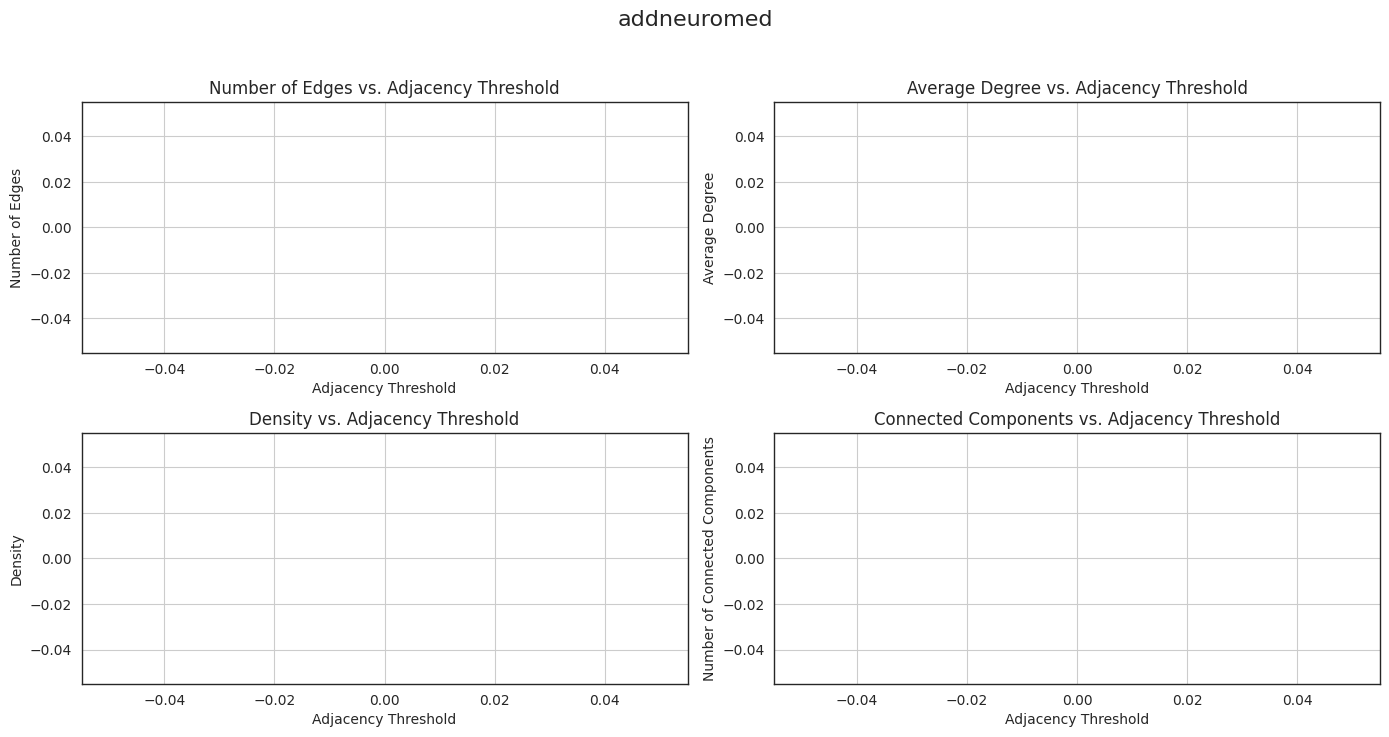

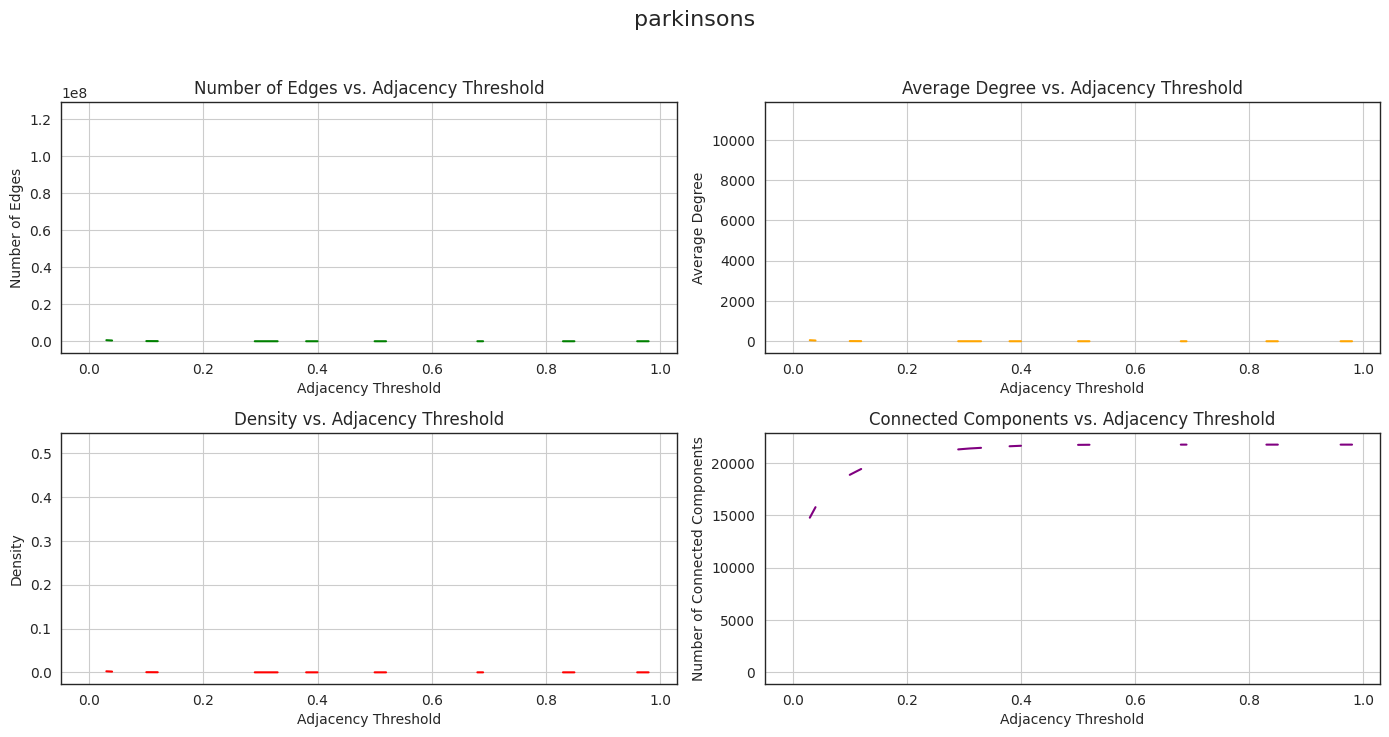

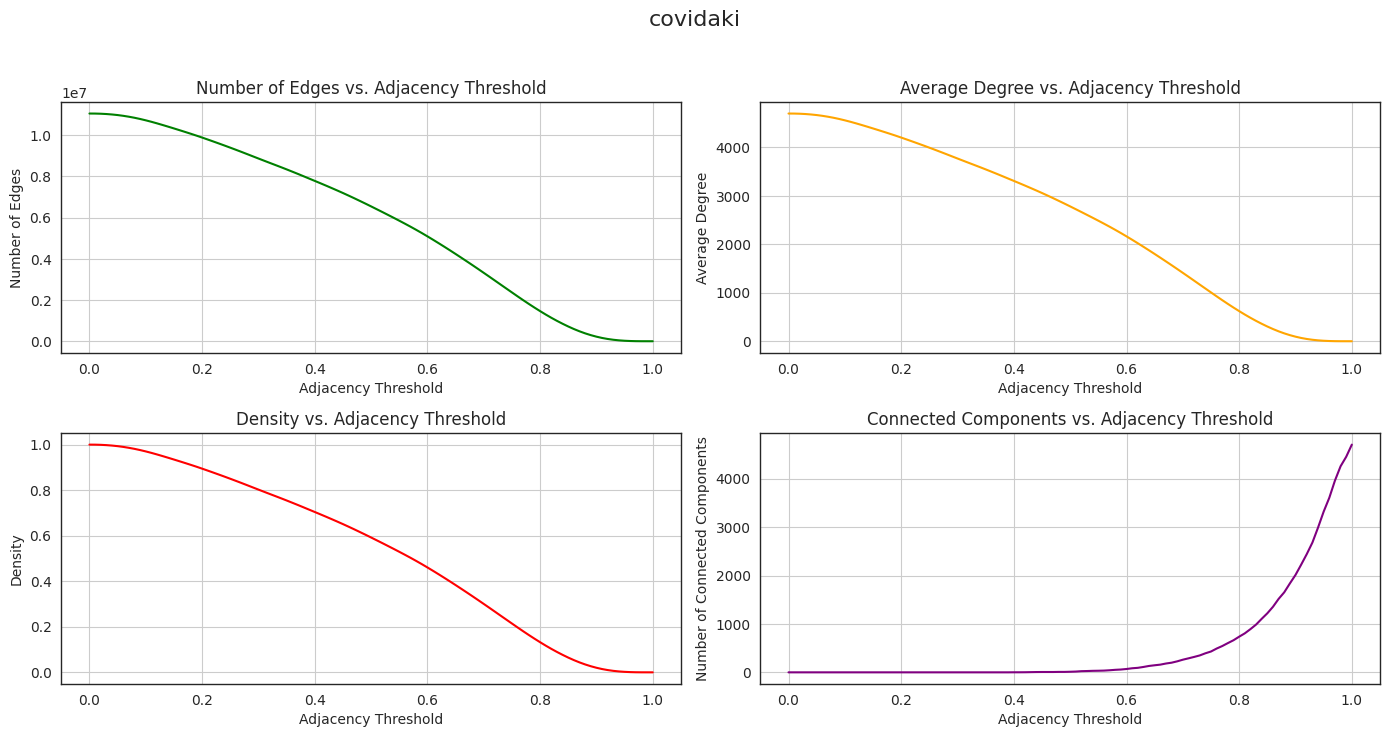

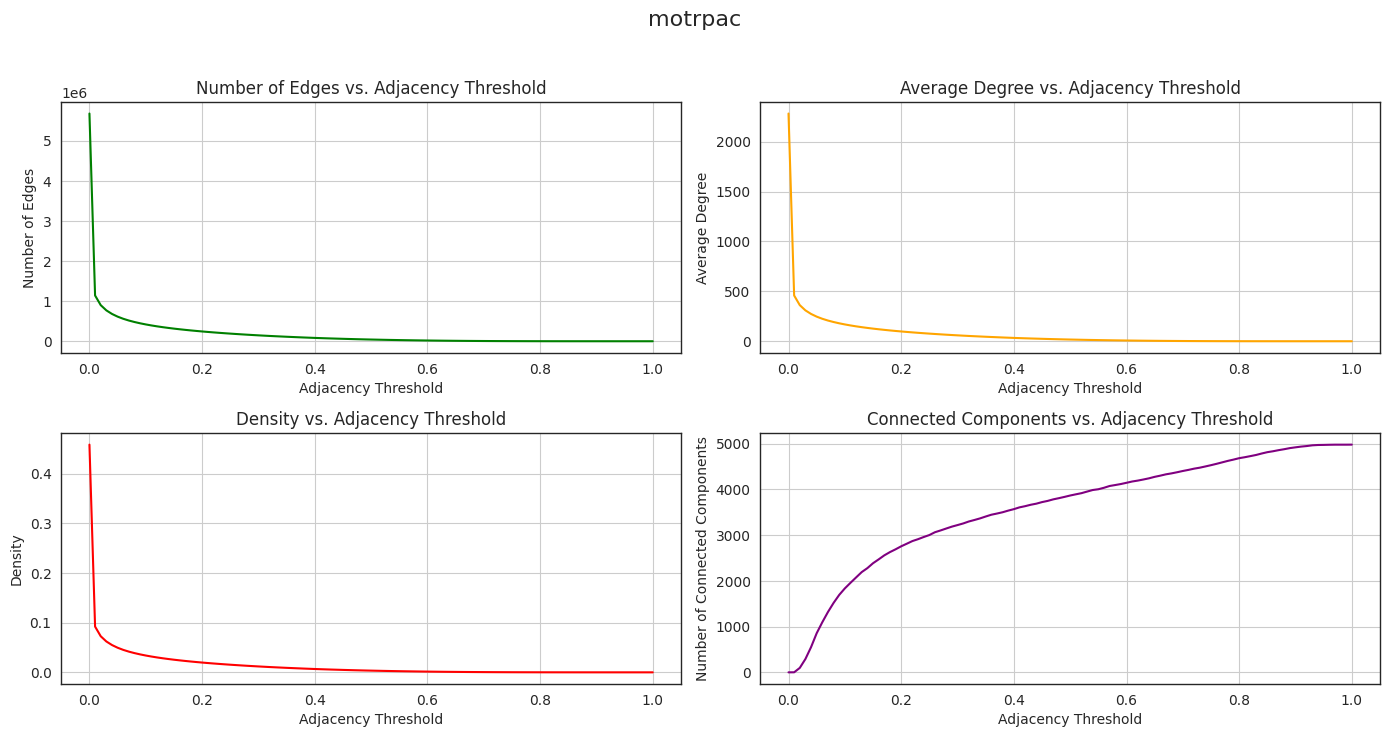

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

for datasets in ["addneuromed", "parkinsons", "covidaki", "motrpac"]:
    csv_file = f"./stats/{datasets}/graph_stats.csv"
    df = pd.read_csv(csv_file)
    # Sort the DataFrame by the 'adj_thresh' column in ascending order
    df = df.sort_values(by="adj_thresh", ascending=True)

    # Plot the evolution of graph statistics with respect to adj_thresh
    plt.figure(figsize=(14, 10))

    # Plot number of edges
    plt.subplot(3, 2, 1)
    plt.plot(df["adj_thresh"], df["num_edges"], label="Number of Edges", color="green")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Number of Edges")
    plt.title("Number of Edges vs. Adjacency Threshold")
    plt.grid(True)

    # Plot average degree
    plt.subplot(3, 2, 2)
    plt.plot(df["adj_thresh"], df["avg_degree"], label="Average Degree", color="orange")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Average Degree")
    plt.title("Average Degree vs. Adjacency Threshold")
    plt.grid(True)

    # Plot density
    plt.subplot(3, 2, 3)
    plt.plot(df["adj_thresh"], df["density"], label="Density", color="red")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Density")
    plt.title("Density vs. Adjacency Threshold")
    plt.grid(True)

    # Plot number of connected components
    plt.subplot(3, 2, 4)
    plt.plot(df["adj_thresh"], df["number_connected_components"], label="Connected Components", color="purple")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Number of Connected Components")
    plt.title("Connected Components vs. Adjacency Threshold")
    plt.grid(True)

    plt.suptitle(datasets, fontsize=16, y=1.02)
    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()

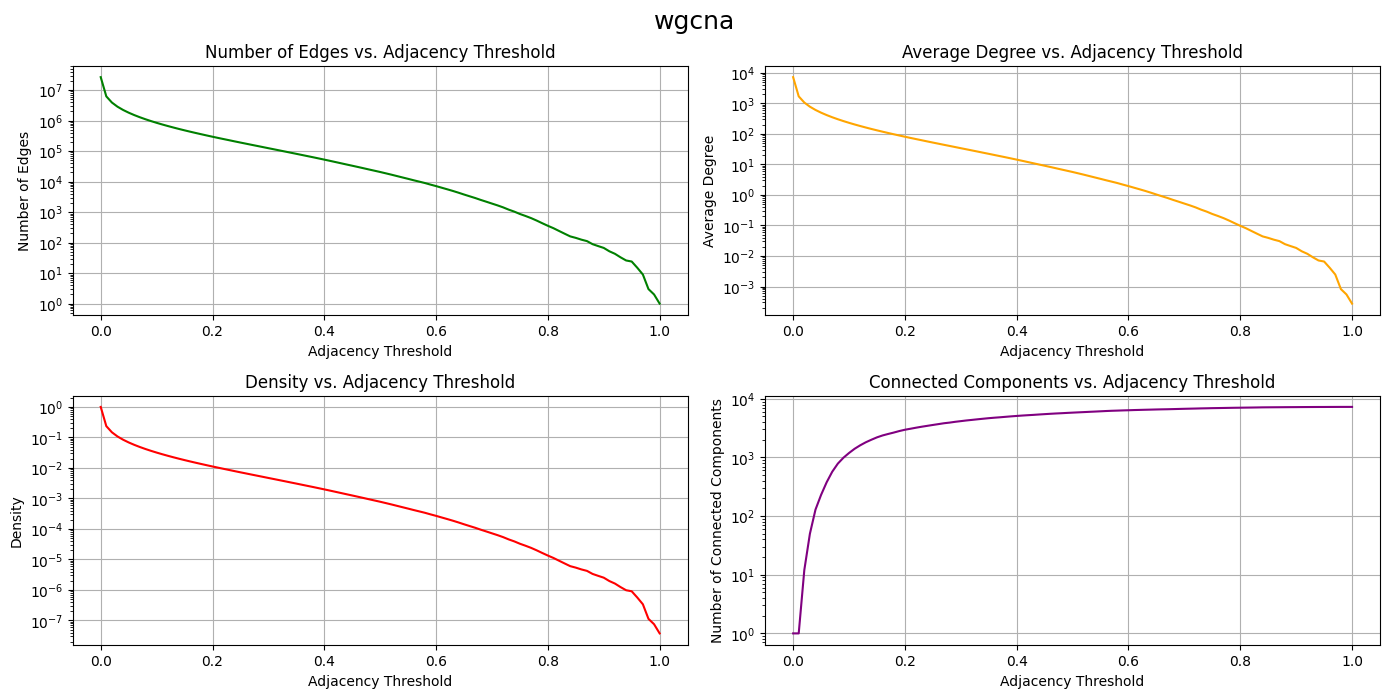

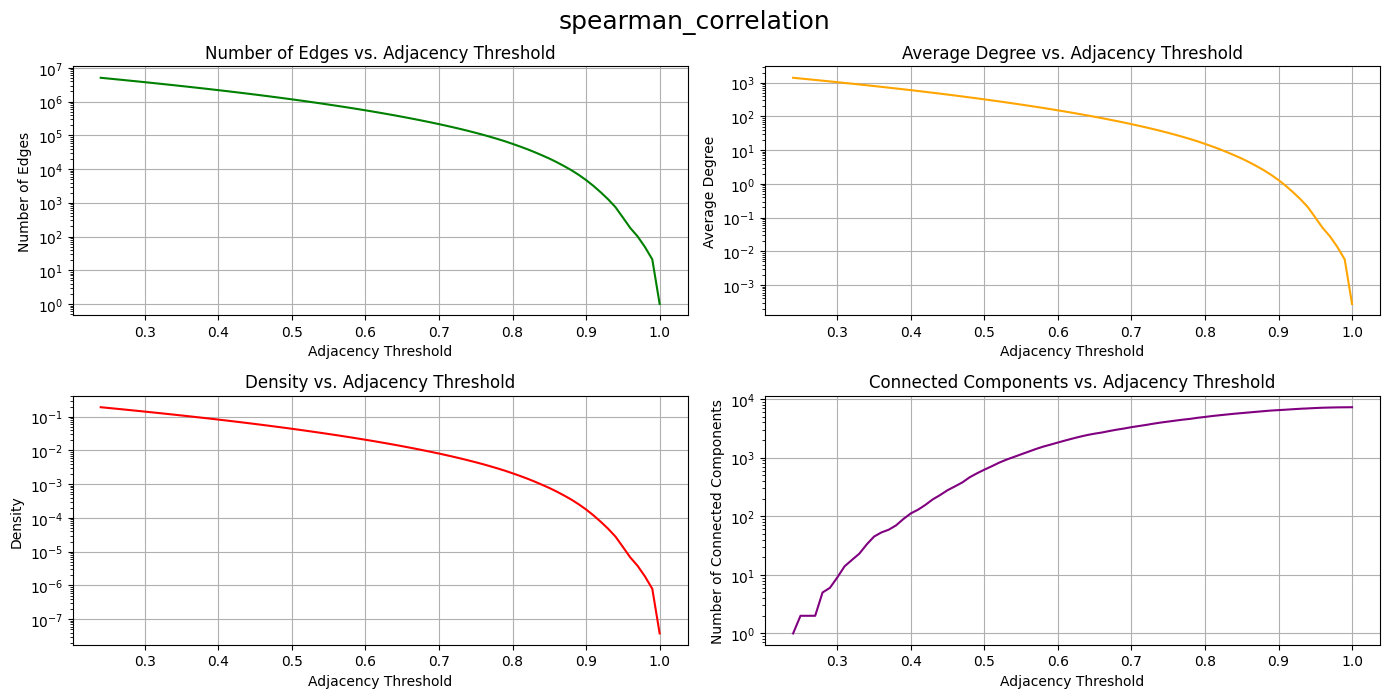

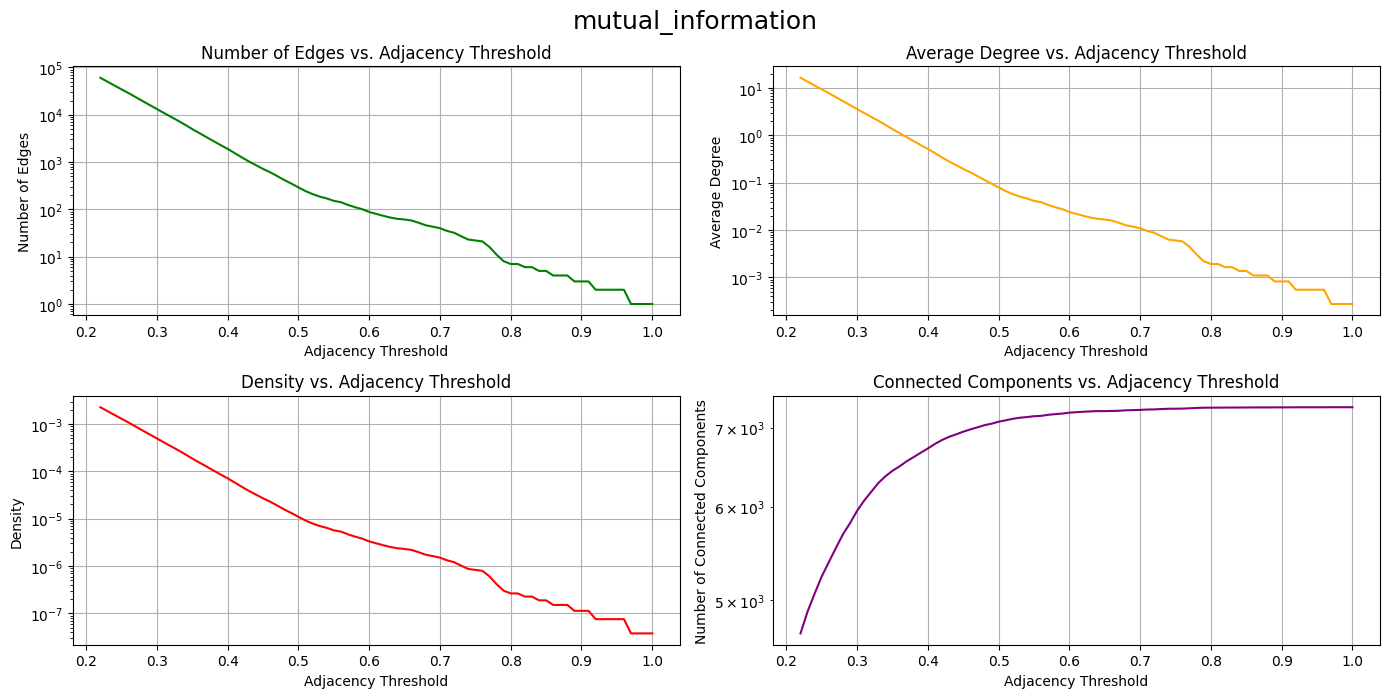

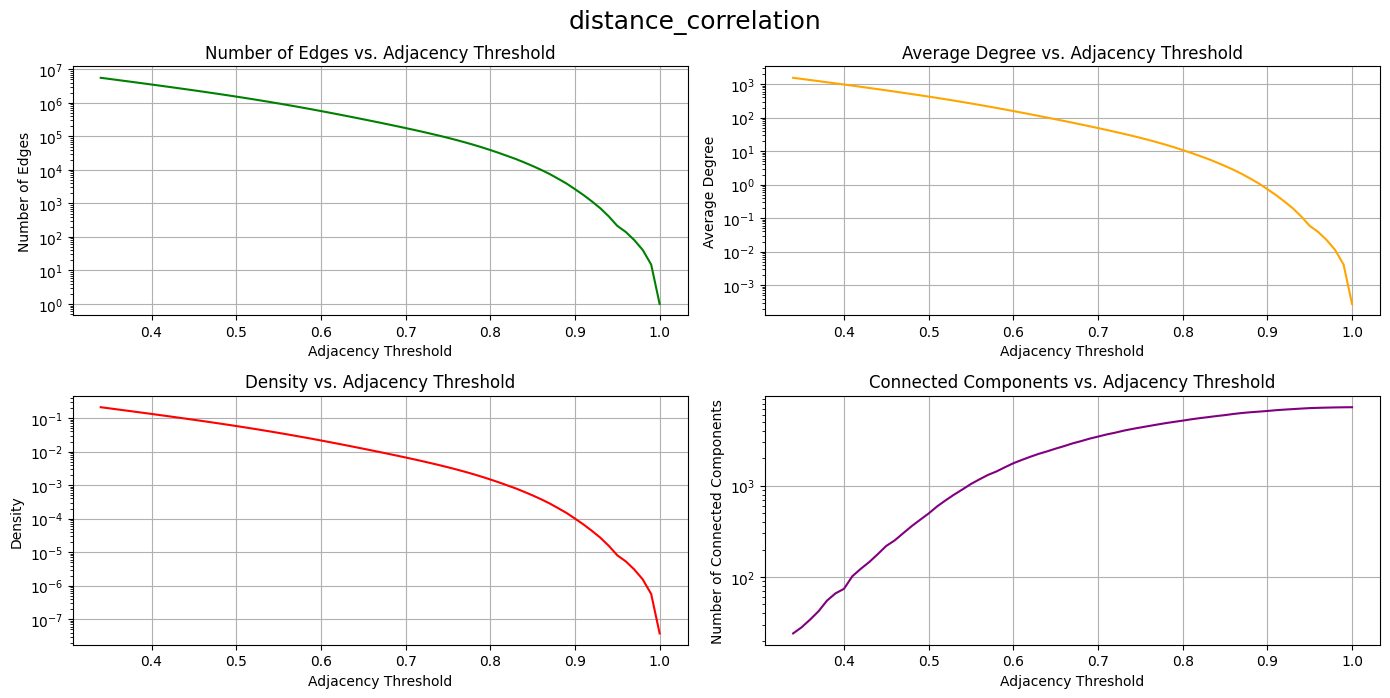

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt

metrics = ["wgcna", "spearman_correlation", "mutual_information", "distance_correlation"]

for metric in metrics:
    # Load the CSV file into a pandas DataFrame
    csv_file = "./stats/"+metric+"/graph_stats.csv"
    df = pd.read_csv(csv_file)
    # Sort the DataFrame by the 'adj_thresh' column in ascending order
    df = df.sort_values(by="adj_thresh", ascending=True)

    # Plot the evolution of graph statistics with respect to adj_thresh
    plt.figure(figsize=(14, 10))
    plt.suptitle(metric, fontsize=18)

    # Plot number of edges
    plt.subplot(3, 2, 1)
    plt.plot(df["adj_thresh"], df["num_edges"], label="Number of Edges", color="green")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Number of Edges")
    plt.title("Number of Edges vs. Adjacency Threshold")
    plt.yscale("log")  # Set y-axis to logarithmic scale
    plt.grid(True)

    # Plot average degree
    plt.subplot(3, 2, 2)
    plt.plot(df["adj_thresh"], df["avg_degree"], label="Average Degree", color="orange")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Average Degree")
    plt.title("Average Degree vs. Adjacency Threshold")
    plt.yscale("log")  # Set y-axis to logarithmic scale
    plt.grid(True)

    # Plot density
    plt.subplot(3, 2, 3)
    plt.plot(df["adj_thresh"], df["density"], label="Density", color="red")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Density")
    plt.title("Density vs. Adjacency Threshold")
    plt.yscale("log")  # Set y-axis to logarithmic scale
    plt.grid(True)

    # Plot number of connected components
    plt.subplot(3, 2, 4)
    plt.plot(df["adj_thresh"], df["number_connected_components"], label="Connected Components", color="purple")
    plt.xlabel("Adjacency Threshold")
    plt.ylabel("Number of Connected Components")
    plt.title("Connected Components vs. Adjacency Threshold")
    plt.yscale("log")  # Set y-axis to logarithmic scale
    plt.grid(True)

    # Adjust layout and show the plots
    plt.tight_layout()
    plt.show()
    plt.close()